# Aprendizaje por Refuerzo

El RL es un paradigma de aprendizaje automático donde un agente aprende a tomar decisiones en un entorno para maximizar una recompensa acumulada.

<img
    src="Reinforcement_learning_diagram.png"
    height="300"
    alt="https://en.wikipedia.org/wiki/Reinforcement_learning#/media/File:Reinforcement_learning_diagram.svg" />

<a href="//commons.wikimedia.org/w/index.php?title=User:Megajuice&amp;action=edit&amp;redlink=1" class="new" title="User:Megajuice (page does not exist)">Megajuice</a> - <span class="int-own-work" lang="en">Own work</span>, <a href="http://creativecommons.org/publicdomain/zero/1.0/deed.en" title="Creative Commons Zero, Public Domain Dedication">CC0</a>, <a href="https://commons.wikimedia.org/w/index.php?curid=57895741">Link</a>

+ Diferencia con supervisado:
    - Supervisado: tienes “respuestas correctas” para cada entrada.
    - RL: no hay respuesta directa, solo un feedback (recompensa) sobre las acciones tomadas.

La idea clave es aprender qué hacer en cada situación para lograr el mejor resultado a largo plazo.

## Conceptos básicos
+ Agente: El que toma las decisiones, interactúa con el entorno y aprende de él.
+ Entorno: El mundo en el que opera el agente y del que recibe retroalimentación.
+ Acción: Una decisión del agente que afecta al entorno.
+ Recompensa: Una señal que indica al agente cuán buena o mala fue su acción.
+ Estado: Una instantánea del entorno en un momento dado.
+ Política: La estrategia del agente para elegir acciones según el estado actual.
+ Función de Valor: Una medida de cuán bueno es un estado o una acción, basada en las recompensas esperadas a lo largo del tiempo.

<img
    src="the-general-framework-of-reinforcement-learning.webp"
    height="500"
    alt="https://www.scribbr.co.uk/using-ai-tools/reinforcement-learning-explained/" />

## Ejemplo didáctico intuitivo: “El ratón en el laberinto”:
+ Un ratón está en un laberinto y quiere llegar al queso.
+ Cada movimiento es una acción.
+ Cada posición es un estado.
+ Al acercarse al queso → recompensa positiva.
+ Al chocar con la pared → recompensa negativa.
+ El ratón aprende por ensayo y error cuál es el camino óptimo.

<img
    src="19-Reinforcement-Learning-RL.png"
    height="400"
    alt="https://glasswing.vc/blog/ai-atlas-19-reinforcement-learning-rl/" />

## Modelo de Decisión de Markov (MDP) 

Un MDP formaliza el entorno para RL: Markov significa que el siguiente estado depende solo del estado actual y la acción tomada, no de todo el historial.

+ S → conjunto de estados
+ A → conjunto de acciones
+ P(s′∣s,a) → probabilidad de transición del estado s a s′ al tomar acción 
+ R(s,a,s′) → recompensa al tomar acción a en estado s y llegar a s′
+ γ → factor de descuento, mide la importancia de recompensas futuras

## Pasos generales en Aprendizaje por Refuerzo (RL)

1. Definir el entorno y el agente
    - Identificar los estados (S), acciones (A) y recompensas (R).
    - Ejemplo: Gridworld 4x4, FrozenLake, sistema de recomendación.
2. Inicializar política: 
    - La política ($π$) indica qué acción tomar en cada estado.
    - Inicialmente puede ser aleatoria (exploración).
3. Inicializar valores
    - Función de valor $V(s)$ o $Q(s,a)$, generalmente con ceros.
4. Loop de interacción con el entorno
    - Repetir para cada episodio o paso:
    - 4.1. Observar estado actual $s$
    - 4.2. Elegir acción $\alpha$ según la política (ej. ε-greedy)
    - 4.3. Ejecutar acción en el entorno → obtener:
        * Nuevo estado $s′$
        * Recompensa $r$
    - 4.4. Actualizar valores según la estrategia de aprendizaje (Value Iteration, Policy Gradient, Q-learning, etc.)
    - 4.5. Actualizar política si aplica
5. Repetir episodios: El agente mejora su política y valores hasta converger a una estrategia óptima.

## Algoritmo Q-Learning
+ Objetivo: aprender $Q(s, a)$ sin conocer $P(s^{'}|s,a)$ (modelo-free)

1. Inicializar $Q(s,a) = 0$ para todos los estados y acciones.
2. Por cada episodio: Colocar al agente en el estado inicial $s_0$.
3. Por cada paso dentro del episodio:
    - 3.1. Elegir acción $a$ usando política ε-greedy:
        * Con probabilidad ε → acción aleatoria (exploración)
        * Con probabilidad 1-ε → acción con máximo Q(s,a) (explotación)
    - 3.2. Ejecutar acción → obtener:
        * Nuevo estado $s′$
        * Recompensa r
    - 3.3. Actualizar Q-value:$Q(s,a)←Q(s,a)+\alpha[r+\gamma max_{a^{'}}Q(s′ ,a′)−Q(s,a)]$
    - 3.4. Actualizar estado: $s←s′$
    - 3.5. Si es estado terminal, terminar el episodio.
4. Repetir episodios hasta que Q-values converjan.

+ Regla de actualización: 
Update rule: $Q(s,a)←Q(s,a)+\alpha[r+\gamma max_{a^{'}}Q(s′ ,a′)−Q(s,a)]$
+ $\alpha$ → tasa de aprendizaje
+ $\gamma$ → factor de descuento
+ s: el estado actual del agente (donde estoy ahora).
+ a: la acción actual que el agente decide ejecutar en $s$
+ $r$: la recompensa que recibe tras ejecutar $a$
+ $s′$ : el nuevo estado al que llegamos después de ejecutar la acción $a$
+ $a′$ : las posibles acciones que se pueden tomar desde el nuevo estado $s′$​	
+ $max_{a^{'}}Q(s′ ,a′)$: el mejor valor posible en el nuevo estado $s′$, considerando todas las acciones $a′$.
Idea: el agente mejora su estimación de la recompensa de cada acción por ensayo y error.

Imagina que estás en un pasillo:
1. Estado actual $s$: estás en la casilla 2.
2. Acción $a$: decides avanzar a la derecha.
3. Nuevo estado $s′$: ahora estás en la casilla 3.
4. Acciones posibles $a′$: en la casilla 3 puedes ir a la derecha o izquierda.
5. $max_{a^{'}}Q(s′ ,a′)$: miras en tu tabla Q cuál de esas acciones parece mejor, y usas el valor más alto.

Ese valor se propaga hacia atrás: si desde la casilla 3 hay un camino prometedor hacia la recompensa, entonces la acción de haber ido de la casilla 2 a la 3 también debe subir su valor.

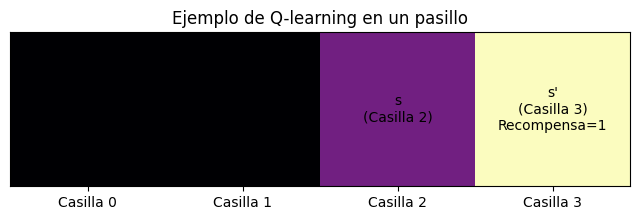

In [27]:
import numpy as np
import matplotlib.pyplot as plt

# Pasillo de 4 casillas
grid = np.zeros((1,4))

# Estados
s = 2   # estado actual
s_next = 3  # nuevo estado
reward_state = 3

# Colores: 0=vacío, 1=actual, 2=siguiente, 3=recompensa
grid[0, s] = 1
grid[0, s_next] = 2
grid[0, reward_state] = 3

plt.figure(figsize=(8,2))
plt.imshow(grid, cmap="magma", aspect="auto")

# Etiquetas
for j in range(4):
    text = ""
    if j == s:
        text = "s\n(Casilla 2)"
    elif j == s_next:
        text = "s'\n(Casilla 3)"
    if j == reward_state:
        text += "\nRecompensa=1"
    plt.text(j, 0, text, ha='center', va='center', color="black", fontsize=10)

plt.title("Ejemplo de Q-learning en un pasillo")
plt.xticks(range(4), [f"Casilla {j}" for j in range(4)])
plt.yticks([])
plt.show()


In [4]:
import numpy as np

# Gridworld 4x4
rewards = np.zeros((4,4)) #Ambiente
rewards[3,3] = 1  # Estado objetivo con recompensa positiva
# Q-table: matriz de acción-valor
# Dimensiones: filas, columnas, acciones
q_values = np.zeros((4,4,4))  # arriba, abajo, izquierda, derecha
gamma = 0.9 #Factor de descuento: peso de las recompensas futuras
alpha = 0.1 #Tasa de aprendizaje: qué tanto actualizamos con lo nuevo

In [5]:
# Función de elección de acción - Política epsilon-greedy: balance entre explorar y explotar
def choose_action(state, epsilon=0.1):
    if np.random.rand() < epsilon: # Explorar
        return np.random.randint(4) # Elegir acción aleatoria
    return np.argmax(q_values[state]) # Explotar (usar la mejor acción conocida)


In [14]:
# Ejemplo de actualización Q-learning
state = (0,0) # Estado inicial
action = choose_action(state) # Acción tomada
new_state = (0,1)  # Nuevo estado después de la acción(suponemos que se mueve a la derecha)
reward = rewards[new_state] #Recompensa obtenida

#Actualización de la Q-table (regla central de Q-learning)
q_values[state + (action,)] += alpha * (reward + gamma * np.max(q_values[new_state]) - q_values[state + (action,)])

In [20]:
# Parámetros
grid_size = 4
rewards = np.zeros((grid_size,grid_size))
rewards[3,3] = 1
q_values = np.zeros((grid_size,grid_size,4))  # Q-table
gamma = 0.9
alpha = 0.1
episodes = 500

# Acciones: 0=arriba, 1=abajo, 2=izquierda, 3=derecha
actions = [(-1,0),(1,0),(0,-1),(0,1)]

def step(state, action):
    x,y = state
    dx,dy = actions[action]
    nx,ny = x+dx, y+dy
    # Limitar dentro de la cuadrícula
    nx = max(0,min(grid_size-1,nx))
    ny = max(0,min(grid_size-1,ny))
    return (nx,ny), rewards[nx,ny]

# Entrenamiento
for ep in range(episodes):
    state = (0,0)
    done = False
    while not done:
        action = choose_action(state, epsilon=0.2)  # más exploración al inicio
        new_state, reward = step(state, action)

        # Actualización Q-learning
        q_values[state + (action,)] += alpha * (
            reward + gamma * np.max(q_values[new_state]) - q_values[state + (action,)]
        )

        state = new_state
        if state == (3,3):
            done = True

# Evaluación (seguir política greedy)
state = (0,0)
path = [state]
while state != (3,3):
    action = np.argmax(q_values[state])
    state,_ = step(state, action)
    path.append(state)

print("Ruta aprendida por el agente:", path)


Ruta aprendida por el agente: [(0, 0), (0, 1), (0, 2), (1, 2), (1, 3), (2, 3), (3, 3)]


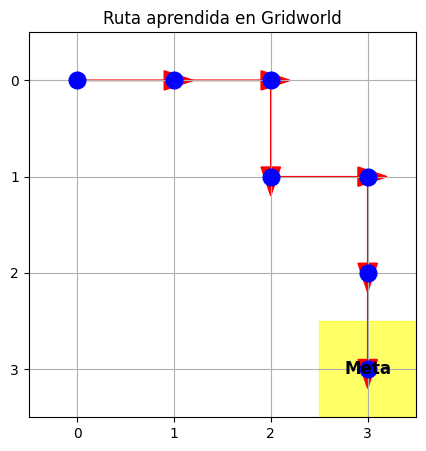

In [21]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(5,5))
ax.set_xlim(-0.5, grid_size-0.5)
ax.set_ylim(-0.5, grid_size-0.5)
ax.set_xticks(range(grid_size))
ax.set_yticks(range(grid_size))
ax.grid(True)

# Dibujar objetivo
ax.add_patch(plt.Rectangle((3-0.5,3-0.5),1,1, color="yellow", alpha=0.6))
ax.text(3,3,"Meta", ha="center", va="center", fontsize=12, weight="bold")

# Dibujar la ruta
for (x,y) in path:
    ax.plot(y, x, "bo", markersize=12)  # nodos
for i in range(len(path)-1):
    x1,y1 = path[i]
    x2,y2 = path[i+1]
    ax.arrow(y1, x1, (y2-y1)*0.9, (x2-x1)*0.9, head_width=0.2, color="red")

ax.invert_yaxis()  # Para que (0,0) esté arriba a la izquierda
plt.title("Ruta aprendida en Gridworld")
plt.show()

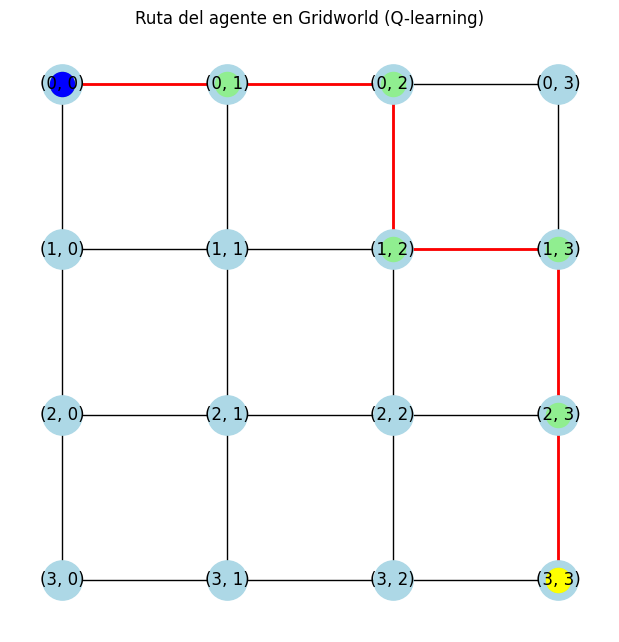

In [22]:
import networkx as nx

G = nx.grid_2d_graph(grid_size, grid_size)  # grafo de la grilla

pos = {(x,y):(y,-x) for x in range(grid_size) for y in range(grid_size)}  # layout

plt.figure(figsize=(6,6))
nx.draw(G, pos, with_labels=True, node_size=800, node_color="lightblue")

# Dibujar ruta aprendida
edges = [(path[i], path[i+1]) for i in range(len(path)-1)]
nx.draw_networkx_nodes(G, pos, nodelist=path, node_color="lightgreen")
nx.draw_networkx_edges(G, pos, edgelist=edges, edge_color="red", width=2)

# Destacar inicio y meta
nx.draw_networkx_nodes(G, pos, nodelist=[(0,0)], node_color="blue")
nx.draw_networkx_nodes(G, pos, nodelist=[(3,3)], node_color="yellow")

plt.title("Ruta del agente en Gridworld (Q-learning)")
plt.show()